# Injecting Strong Lens Simulations into Roman Images with `romanisim`

This notebook demonstrates how to take a **noiseless, PSF-convolved** strong
lens simulation (91×91 pixels at 0.11″/pixel) and produce a realistic Nancy
Grace Roman Space Telescope L2 image using
[romanisim](https://github.com/spacetelescope/romanisim).

Two modes are shown:
1. **Without CRDS** — uses romanisim's built-in default reference data  
2. **With CRDS** — pulls real calibration files from the Roman CRDS server

---

## Strategy

We use the `extra_counts` parameter of `romanisim.image.simulate()`.  This
injects an array of electron counts directly into the idealized counts image
*before* the L1 pipeline runs (resultant apportioning via binomial draws, read
noise, IPC, cosmic rays, nonlinearity) and before L2 ramp fitting.

### Why PSF-convolved input?

The `extra_counts` path bypasses romanisim's source rendering and PSF
convolution entirely.  Your noiseless image is treated as a map of "extra
electrons that landed on the detector."  The L1 pipeline then naturally adds
all the realistic noise.

If you provided **unconvolved** images you would need to either:
- route through GalSim's `RealGalaxyCatalog` (which deconvolves an assumed PSF
  and reconvolves with Roman's — prone to ringing for extended lensed arcs), or
- manually convolve with the Roman PSF yourself.

Since lens-modeling codes (lenstronomy / PyAutoLens / etc.) already produce
PSF-convolved images with the appropriate Roman PSF, feeding those directly is
both simpler and more accurate.

In [1]:
import numpy as np
import galsim
from galsim import roman
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm, CenteredNorm
from copy import deepcopy
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

import romanisim.bandpass
import romanisim.image as rsim_image
import romanisim.wcs as rsim_wcs
import romanisim.parameters as rsim_params
import romanisim.util as rsim_util
import romanisim
romanisim.__version__

import mejiro
from mejiro.galaxy_galaxy import Sample1, Sample2, SampleGG
from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.utils import util

2026-03-19 09:45:12 INFO     Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2026-03-19 09:45:12 INFO     Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-03-19 09:45:12 INFO     NumExpr defaulting to 16 threads.


## 1. Define your inputs

Replace the placeholder stamp and flux with your actual lens simulation.
The stamp must be:
- **PSF-convolved** (convolved with the appropriate Roman PSF for the filter
  and SCA you are simulating)
- **Noiseless** (no Poisson, read, or background noise)
- At the **native Roman pixel scale** of 0.11″/pixel

In [2]:
rng_demo = np.random.default_rng(42)

# Where to place it (pixel coords in the full 4088×4088 frame)
inject_x, inject_y = 2044, 2044
detector_position = (inject_x, inject_y)

# ── Observation parameters ──────────────────────────────────────────────
band = 'F129'
sca            = 1                 # WFI01
ma_table_number = 4
date           = "2027-01-01T00:00:00"
coord          = SkyCoord(ra=270.0 * u.deg, dec=66.0 * u.deg)

Loading cached PSF: /data/bwedig/mejiro/cached_psfs/F129_1_2044_2044_5_101.npy


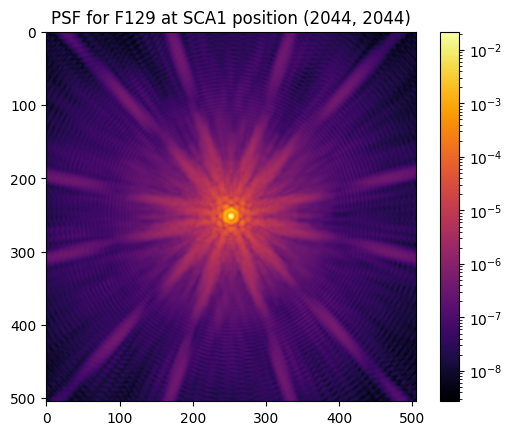

In [3]:
psf_cache_dir = '/data/bwedig/mejiro/cached_psfs'

kwargs_psf = STPSFEngine.get_roman_psf_kwargs(band, sca, detector_position, oversample=5, num_pix=101, check_cache=True, psf_cache_dir=psf_cache_dir, verbose=True)

plt.imshow(kwargs_psf['kernel_point_source'], norm=LogNorm(), cmap='inferno')
plt.colorbar()
plt.title(f'PSF for {band} at SCA{sca} position {detector_position}')
plt.show()

Scene size: 10.01 arcsec, 91 pixels at pixel scale 0.11 arcsec/pix
Synthetic image calculation time: 0.422 s


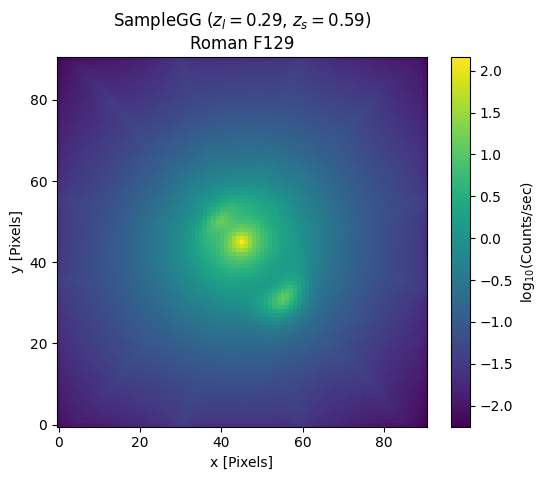

Shape: (91, 91)
Flux: 4566.706896922136
Maggies: 1.3546972930338537e-07


In [4]:
sample = SampleGG()
# sample = Sample1()
roman_instrument = Roman()
synth = SyntheticImage(sample, band=band, instrument=roman_instrument, fov_arcsec=10, kwargs_psf=kwargs_psf)
synth.plot()

flux = synth.get_flux()
maggies = synth.get_maggies()

print(f'Shape: {synth.image.shape}')
print(f'Flux: {flux}')
print(f'Maggies: {maggies}')

## 2. Convert flux to total electrons

`romanisim.bandpass.get_abflux(filter, sca)` returns the count rate
(electrons s⁻¹) for a source with 1 maggy of flux (i.e., an AB-magnitude-zero
source).  Multiplying by the exposure time and by the source flux in maggies
gives the total number of electrons deposited on the detector.

In [5]:
# AB zero-point flux: electrons/s
abflux = romanisim.bandpass.get_abflux(band, sca)
print(f"AB zero-point flux for {band}, SCA{sca}: {abflux:.3e} e/s")

# Exposure time from the MA table
read_pattern = rsim_params.read_pattern[ma_table_number]
exptime = rsim_params.read_time * read_pattern[-1][-1]
print(f"Total exposure time (MA table {ma_table_number}): {exptime:.1f} s")

# Total electrons from the lens system
total_electrons = maggies * abflux * exptime
print(f"Lens flux: {maggies:.3e} maggies "
      f"(AB mag {-2.5*np.log10(maggies):.1f})")
print(f"Total electrons from lens: {total_electrons:.1f}")

# Scale the normalized stamp to electrons
lens_electrons = (synth.image / np.sum(synth.image)) * total_electrons

AB zero-point flux for F129, SCA1: 3.371e+10 e/s
Total exposure time (MA table 4): 139.1 s
Lens flux: 1.355e-07 maggies (AB mag 17.2)
Total electrons from lens: 635489.9


## 3. Build the `extra_counts` array

The `extra_counts` array must match the full detector shape
(`galsim.roman.n_pix` × `galsim.roman.n_pix` = 4088 × 4088).  We embed the
91×91 stamp at the desired pixel location, handling edge-clipping if the stamp
overlaps the detector boundary.

In [6]:
def build_extra_counts(stamp, center_x, center_y, npix=None, rng_seed=None):
    """Place a stamp into a full-frame extra_counts array.

    The stamp (expected electron counts, float) is Poisson-sampled to produce
    integer realized counts.  This is necessary because romanisim's
    ``apportion_counts_to_resultants`` requires integer input, and also
    correctly introduces the Poisson noise for the injected source.  The
    subsequent binomial apportioning in the L1 pipeline then distributes
    these realized photons across individual reads.

    Parameters
    ----------
    stamp : np.ndarray
        2D array of *expected* electron counts (noiseless, PSF-convolved).
    center_x, center_y : int
        Pixel coordinates of the stamp center in the full frame.
    npix : int, optional
        Size of the full frame.  Defaults to galsim.roman.n_pix.
    rng_seed : int, optional
        Seed for the Poisson draw.  None for non-reproducible.

    Returns
    -------
    extra : galsim.Image
        Full-frame integer-valued image with the Poisson-sampled stamp
        embedded.
    """
    if npix is None:
        npix = roman.n_pix

    extra = np.zeros((npix, npix), dtype=np.int32)
    sy, sx = stamp.shape
    half_y, half_x = sy // 2, sx // 2

    # Compute slicing bounds with edge-clipping
    y_lo, x_lo = center_y - half_y, center_x - half_x
    y_hi, x_hi = y_lo + sy, x_lo + sx

    stamp_y_lo = max(0, -y_lo)
    stamp_x_lo = max(0, -x_lo)
    stamp_y_hi = sy - max(0, y_hi - npix)
    stamp_x_hi = sx - max(0, x_hi - npix)

    y_lo_c = max(0, y_lo)
    x_lo_c = max(0, x_lo)
    y_hi_c = min(npix, y_hi)
    x_hi_c = min(npix, x_hi)

    # Poisson-sample the expected counts to get integer realized counts.
    # This is the correct noise model: the stamp gives the expected number
    # of photons per pixel, and Poisson sampling gives the actual number
    # that arrived during the exposure.
    rng_np = np.random.default_rng(rng_seed)
    clipped = np.clip(stamp[stamp_y_lo:stamp_y_hi, stamp_x_lo:stamp_x_hi],
                      0, None)
    realized = rng_np.poisson(clipped).astype(np.int32)

    extra[y_lo_c:y_hi_c, x_lo_c:x_hi_c] = realized

    return galsim.ImageI(extra)   # ImageI for integer type

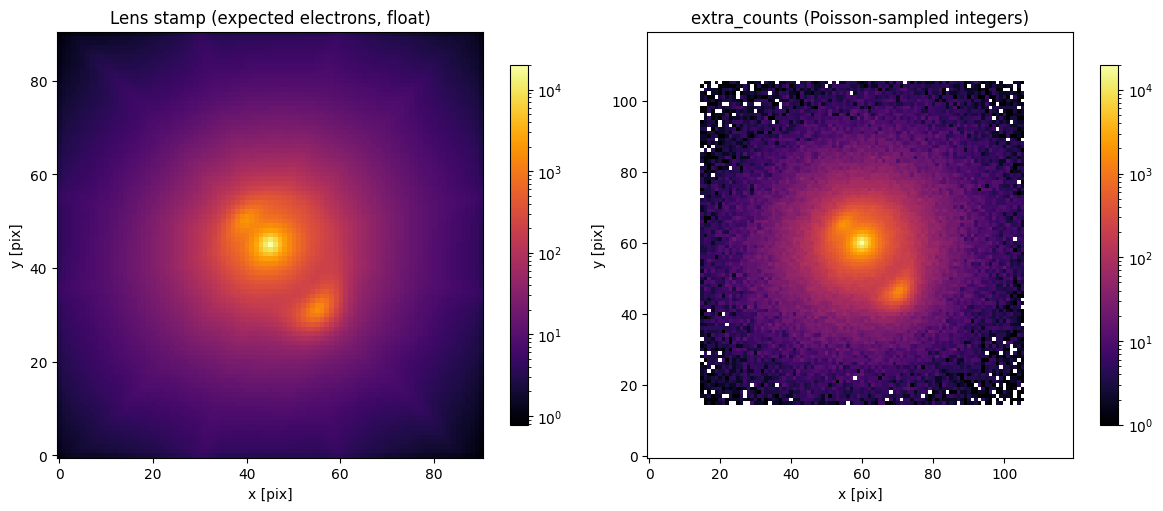

extra_counts dtype:  int32
Total expected e⁻:  635489.9
Total realized e⁻:  634374


In [7]:
extra_counts = build_extra_counts(lens_electrons, inject_x, inject_y,
                                  rng_seed=12345)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(lens_electrons, origin="lower",
               norm=LogNorm(),
               cmap="inferno")
axes[0].set_title("Lens stamp (expected electrons, float)")
axes[0].set_xlabel("x [pix]");  axes[0].set_ylabel("y [pix]")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

margin = 60
sl = (slice(inject_y - margin, inject_y + margin),
      slice(inject_x - margin, inject_x + margin))
im1 = axes[1].imshow(extra_counts.array[sl], origin="lower",
               norm=LogNorm(),
               cmap="inferno")
axes[1].set_title(f"extra_counts (Poisson-sampled integers)")
axes[1].set_xlabel("x [pix]");  axes[1].set_ylabel("y [pix]")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# Verify the counts are integers
print(f"extra_counts dtype:  {extra_counts.array.dtype}")
print(f"Total expected e⁻:  {np.sum(lens_electrons):.1f}")
print(f"Total realized e⁻:  {np.sum(extra_counts.array)}")

## 4a. Simulate WITHOUT CRDS (default reference data)

This uses romanisim's built-in defaults for gain (2 e⁻/DN), read noise
(5 DN), flat (unity), etc.  The WCS comes from GalSim's Roman module.  Good
for quick testing and science forecasting.

In [8]:
def simulate_lens_no_crds(extra_counts, band, sca, ma_table_number,
                          coord, date, rng_seed=42, level=2,
                          crparam=dict(), catalog=None):
    """Run romanisim with injected lens counts, no CRDS.

    Parameters
    ----------
    extra_counts : galsim.Image or np.ndarray
        Full-frame extra electron counts to inject.
    band : str
        Roman filter (e.g. 'F158').
    sca : int
        SCA number (1–18).
    ma_table_number : int
        MA table number.
    coord : SkyCoord
        Boresight pointing.
    date : str
        ISO 8601 date string.
    rng_seed : int
        Random seed for reproducibility.
    level : int
        Output level (1 for L1, 2 for L2).
    crparam : dict or None
        Cosmic-ray parameters.  dict() for defaults, None to skip.
    catalog : astropy.table.Table or None
        Optional source catalog.  If None an empty catalog is used
        (lens only, plus sky + dark).

    Returns
    -------
    im : roman_datamodels node
        Simulated image.
    extras : dict
        Simulation metadata and artifacts.
    """
    from astropy.table import Table

    meta = deepcopy(rsim_params.default_parameters_dictionary)
    meta['instrument']['detector'] = f'WFI{sca:02d}'
    meta['instrument']['optical_element'] = band
    meta['exposure']['ma_table_number'] = ma_table_number
    meta['exposure']['read_pattern'] = rsim_params.read_pattern[ma_table_number]
    meta['exposure']['start_time'] = Time(date, format='isot')
    rsim_wcs.fill_in_parameters(meta, coord, boresight=True)

    if catalog is None:
        catalog = Table({
            'ra': np.array([], dtype='f8'),
            'dec': np.array([], dtype='f8'),
            'type': np.array([], dtype='U3'),
            'n': np.array([], dtype='f4'),
            'half_light_radius': np.array([], dtype='f4'),
            'pa': np.array([], dtype='f4'),
            'ba': np.array([], dtype='f4'),
            band: np.array([], dtype='f4'),
        })

    rng = galsim.UniformDeviate(rng_seed)

    im, extras = rsim_image.simulate(
        meta, catalog,
        usecrds=False,
        psftype='galsim',
        level=level,
        rng=rng,
        crparam=crparam,
        extra_counts=extra_counts,
    )
    return im, extras

## 4b. Simulate WITH CRDS

This pulls real calibration reference files (gain maps, dark current, flat
fields, linearity polynomials, etc.) from the Roman CRDS server.  Requires
CRDS to be configured:

```bash
export CRDS_PATH=$HOME/crds_cache
export CRDS_SERVER_URL=https://roman-crds.stsci.edu
```

In [9]:
def simulate_lens_with_crds(extra_counts, band, sca, ma_table_number,
                            coord, date, rng_seed=42, level=2,
                            crparam=dict(), catalog=None):
    """Run romanisim with injected lens counts, using CRDS reference files.

    Same interface as simulate_lens_no_crds but fetches calibration data
    from CRDS instead of using built-in defaults.
    """
    from astropy.table import Table

    # Clear defaults so CRDS files are fetched
    saved_refdata = {k: v for k, v in rsim_params.reference_data.items()}
    for k in rsim_params.reference_data:
        rsim_params.reference_data[k] = None

    try:
        meta = deepcopy(rsim_params.default_parameters_dictionary)
        meta['instrument']['detector'] = f'WFI{sca:02d}'
        meta['instrument']['optical_element'] = band
        meta['exposure']['ma_table_number'] = ma_table_number
        meta['exposure']['read_pattern'] = rsim_params.read_pattern[ma_table_number]
        meta['exposure']['start_time'] = Time(date, format='isot')
        rsim_wcs.fill_in_parameters(meta, coord, boresight=True)

        if catalog is None:
            catalog = Table({
                'ra': np.array([], dtype='f8'),
                'dec': np.array([], dtype='f8'),
                'type': np.array([], dtype='U3'),
                'n': np.array([], dtype='f4'),
                'half_light_radius': np.array([], dtype='f4'),
                'pa': np.array([], dtype='f4'),
                'ba': np.array([], dtype='f4'),
                band: np.array([], dtype='f4'),
            })

        rng = galsim.UniformDeviate(rng_seed)

        im, extras = rsim_image.simulate(
            meta, catalog,
            usecrds=True,
            psftype='epsf',
            level=level,
            rng=rng,
            crparam=crparam,
            extra_counts=extra_counts,
        )
    finally:
        rsim_params.reference_data.update(saved_refdata)

    return im, extras

In [10]:
# ── Pre-flight saturation check ─────────────────────────────────────────
well_depth_electrons = rsim_params.reference_data['saturation'] * rsim_params.reference_data['gain']
headroom = well_depth_electrons - rsim_params.pedestal  # electrons available for signal
peak_expected = np.max(lens_electrons)

print(f"Well depth:       {well_depth_electrons:,.0f} e⁻")
print(f"Pedestal:         {rsim_params.pedestal:,.0f} e⁻")
print(f"Available:        {headroom:,.0f} e⁻")
print(f"Stamp peak:       {peak_expected:,.1f} e⁻")
print(f"Peak / available: {peak_expected / headroom:.2f}")

if peak_expected > headroom:
    print(f"⚠  Peak exceeds well depth by {peak_expected/headroom:.1f}×.")
    print(f"   The lens galaxy center will saturate — this is physically")
    print(f"   realistic for bright systems but will produce artifacts in")
    print(f"   the L2 ramp-fit image at those pixels.")
    print(f"   For subhalo detection in the lensed arcs (away from center),")
    print(f"   this is typically fine.")
else:
    print("✓  No pixels will saturate.")

Well depth:       110,000 e⁻
Pedestal:         10,000 e⁻
Available:        100,000 e⁻
Stamp peak:       20,218.2 e⁻
Peak / available: 0.20
✓  No pixels will saturate.


## 5. Quick test with a small detector

For rapid iteration, we shrink the detector to 200×200 pixels and place the
lens at the center.  A full 4088×4088 simulation takes several minutes; this
runs in seconds.

In [11]:
# Shrink the detector for a fast test
original_npix = roman.n_pix
roman.n_pix = 200

inject_x_small, inject_y_small = 100, 100
extra_counts_small = build_extra_counts(
    lens_electrons, inject_x_small, inject_y_small, npix=200, rng_seed=42)

# NOTE: When shrinking the detector, the cosmic ray module still uses the
# physical detector area (16.8 cm²) but deposits all hits on the smaller
# pixel grid.  This inflates the CR rate by ~(4088/200)² ≈ 418×.
# To compensate, scale the CR flux down, or disable CRs entirely.
cr_scale_factor = (200 / 4088)**2
scaled_crparam = dict(flux=8 * cr_scale_factor)  # 8 CR/cm²/s is the default

print("Running quick test (200×200, no CRDS, scaled CR rate)...")
im_test, extras_test = simulate_lens_no_crds(
    extra_counts_small, band, sca, ma_table_number, coord, date,
    crparam=scaled_crparam
    ) 

# Restore the original detector size
roman.n_pix = original_npix
print("Done.")

2026-03-19 09:45:14 WARNING  --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.


Running quick test (200×200, no CRDS, scaled CR rate)...


2026-03-19 09:45:15 INFO     Simulating filter F129...
2026-03-19 09:45:15 INFO     Creating PSF using galsim
2026-03-19 09:45:15 INFO     Creating PSF using galsim
2026-03-19 09:45:15 INFO     Creating PSF using galsim
2026-03-19 09:45:16 INFO     Creating PSF using galsim
2026-03-19 09:45:16 INFO     Adding 0 sources to image...
2026-03-19 09:45:16 WARNING  You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-03-19 09:45:16 INFO     Rendered 0 point sources in 6.53e-05 seconds
2026-03-19 09:45:16 INFO     Rendered 0 total sources in 0.000472 seconds
2026-03-19 09:45:16 INFO     Apportioning electrons to resultants...
2026-03-19 09:45:16 INFO     Adding IPC...
2026-03-19 09:45:16 INFO     Adding read noise...
2026-03-19 09:45:16 INFO     Fitting ramps.
2026-03-19 09:45:16 INFO     Simulation complete.


Done.


## 6. Visualize the result

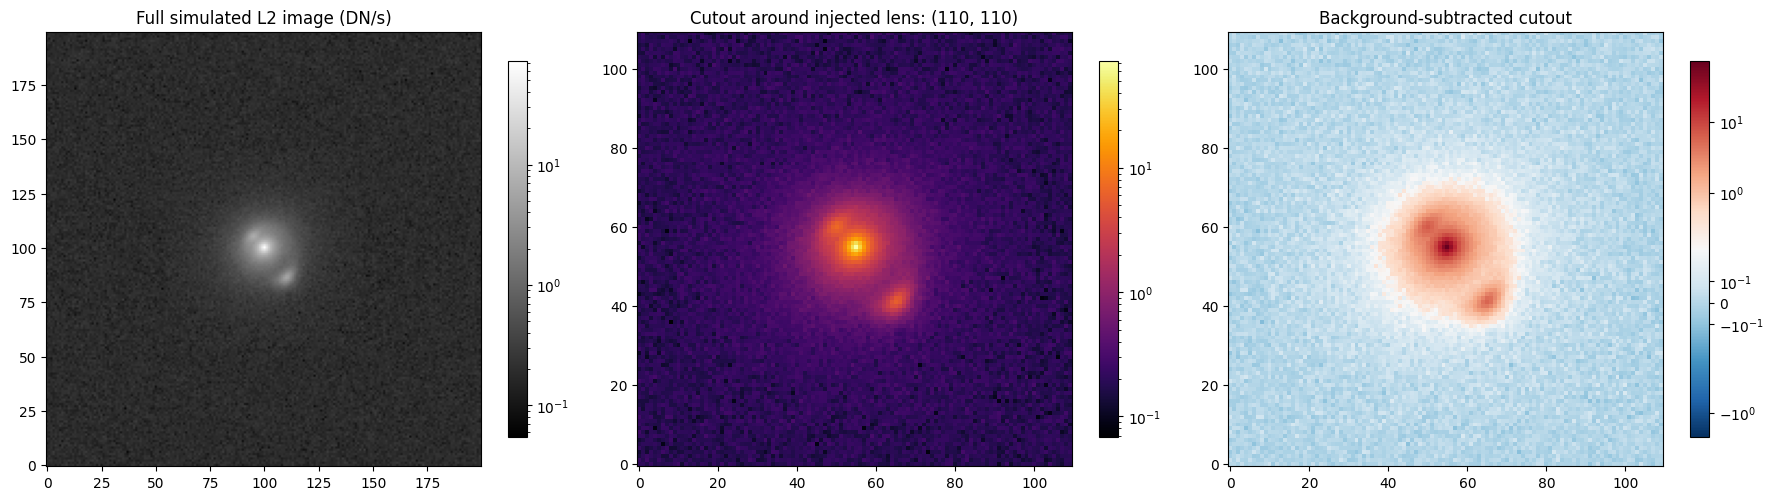

In [12]:
data = im_test.data if hasattr(im_test, 'data') else im_test['data']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full simulated image
im0 = axes[0].imshow(data, origin="lower", cmap="gray", norm=LogNorm())
axes[0].set_title("Full simulated L2 image (DN/s)")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Cutout around the lens
margin = 55
sl = (slice(inject_y_small - margin, inject_y_small + margin),
      slice(inject_x_small - margin, inject_x_small + margin))
cutout = data[sl]
im1 = axes[1].imshow(cutout, origin="lower", cmap="inferno", norm=LogNorm())
axes[1].set_title(f"Cutout around injected lens: {cutout.shape}")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Background-subtracted cutout
bg = np.nanmedian(data)
diff = cutout - bg
im2 = axes[2].imshow(diff, origin="lower", cmap="RdBu_r",
                      norm=SymLogNorm(linthresh=np.nanstd(data) * 0.5,
                                      vmin=-np.nanstd(data) * 3,
                                      vmax=diff.max()))
axes[2].set_title("Background-subtracted cutout")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

Exposure calculation time with galsim engine: 0.022 s
galsim.roman.gain = 1.0 e⁻/ADU
romanisim gain = 2.0 e⁻/DN


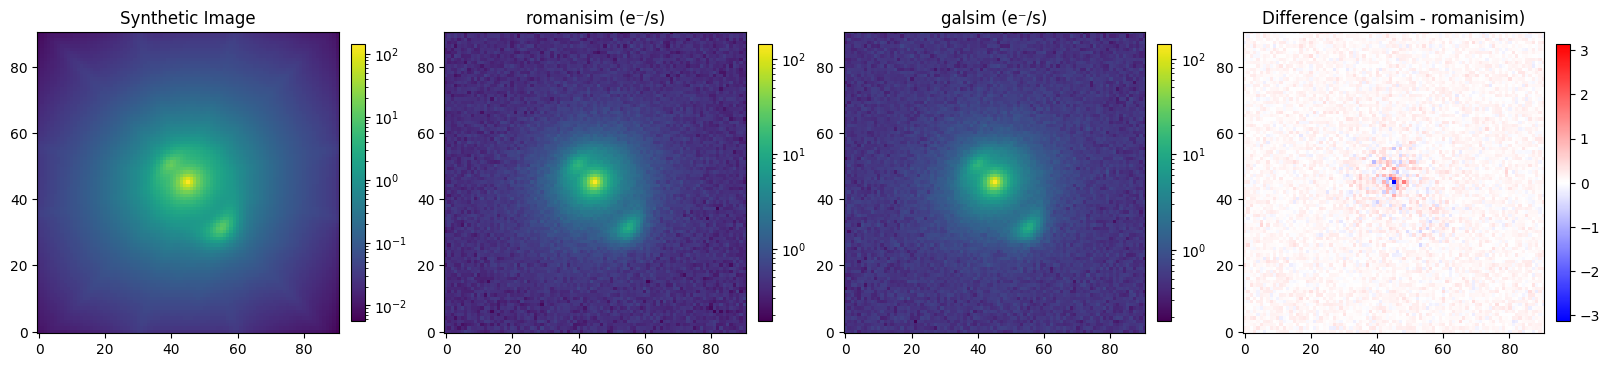

Median ratio (galsim/romanisim) on bright pixels: 1.0388


In [13]:
exposure = Exposure(synth, exptime)

# Convert both to e⁻/s for a fair comparison
# GalSim: exposure.exposure is in ADU; multiply by galsim.roman.gain (1.0 e⁻/ADU) to get electrons
# RomanISim: im_test.data (cutout) is in DN/s; multiply by romanisim gain (2.0 e⁻/DN) to get e⁻/s
romanisim_gain = float(rsim_params.reference_data['gain'])  # 2.0 e⁻/DN
galsim_gain = roman.gain                                          # 1.0 e⁻/ADU

romanisim_cutout = util.center_crop_image(cutout, (91, 91)) * romanisim_gain  # DN/s -> e⁻/s
galsim_rate = (exposure.exposure / exptime) * galsim_gain                      # ADU/s -> e⁻/s

print(f"galsim.roman.gain = {galsim_gain} e⁻/ADU")
print(f"romanisim gain = {romanisim_gain} e⁻/DN")

_, ax = plt.subplots(1, 4, figsize=(16, 5), constrained_layout=True)
img0 = ax[0].imshow(synth.image, origin='lower', norm=LogNorm())
ax[0].set_title('Synthetic Image')

img1 = ax[1].imshow(romanisim_cutout, origin='lower', norm=LogNorm())
ax[1].set_title('romanisim (e⁻/s)')

img2 = ax[2].imshow(galsim_rate, origin='lower', norm=LogNorm())
ax[2].set_title('galsim (e⁻/s)')

img3 = ax[3].imshow(galsim_rate - romanisim_cutout, origin='lower', norm=CenteredNorm(), cmap='bwr')
ax[3].set_title('Difference (galsim - romanisim)')

for i, img in enumerate([img0, img1, img2, img3]):
    plt.colorbar(img, ax=ax[i], fraction=0.046, pad=0.04)
plt.show()

# Quantify the residual
mask = romanisim_cutout > np.percentile(romanisim_cutout, 50)
ratio = np.nanmedian(galsim_rate[mask] / romanisim_cutout[mask])
print(f"Median ratio (galsim/romanisim) on bright pixels: {ratio:.4f}")

### Diagnosing the artifacts

The dark pixels at the lens center are a classic signature of **saturation** in
ramp-fitted data.  Let's inspect the DQ array and the total electron budget to
confirm, and also check how the inflated cosmic ray rate in the small-detector
test mode is affecting the image.

=== L2 DQ Summary (collapsed over all resultants) ===
  Total pixels:          40000
  Saturated pixels:      0 (0.00%)
  CR-flagged pixels:     127 (0.32%)
  Either flag:           127

(Per-resultant L1 DQ not found in extras — this is normal for L2.)


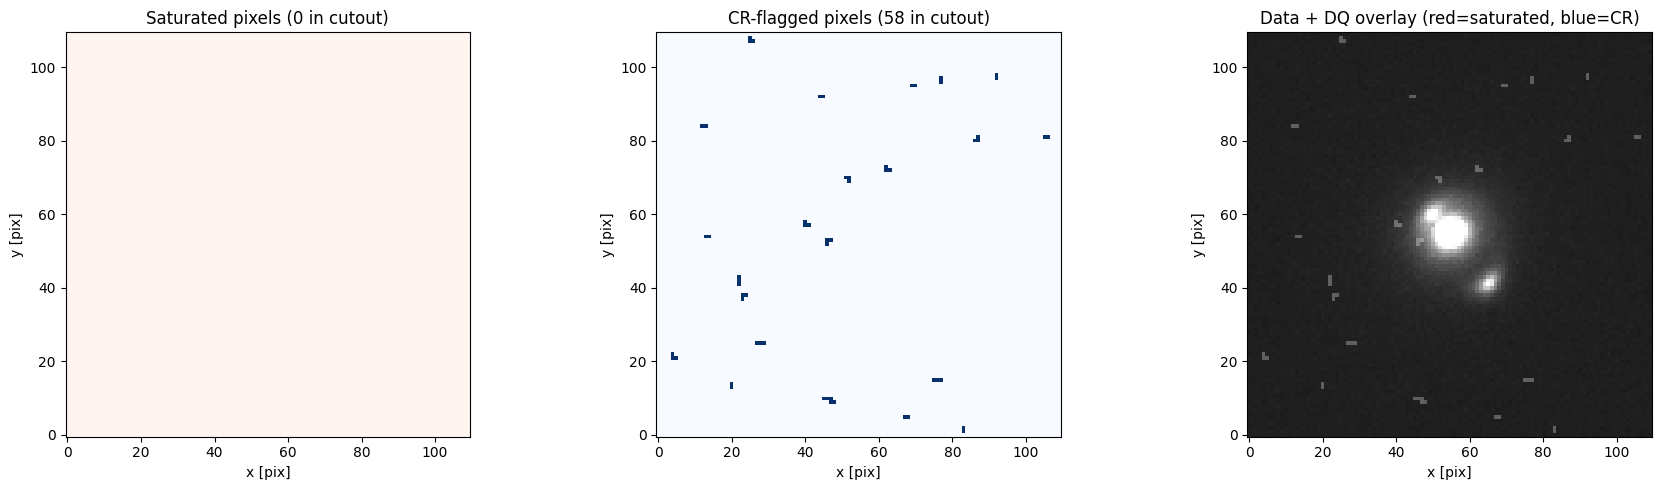


=== Electron budget at brightest lens pixel ===
  Pedestal:            10,000 e⁻
  Lens peak:           20,143 e⁻
  Saturation:          55,000 DN × 2 e⁻/DN = 110,000 e⁻
  Peak / saturation:   0.27
  ✓  Brightest pixel is below saturation.


In [14]:
# ── Check for saturation and CR flags in the DQ array ───────────────────
import romanisim.parameters as rp

# The L2 DQ array lives on the image model, not in extras.
# It is the bitwise OR of all per-resultant DQ flags, collapsed to 2D.
dq_l2 = im_test.dq if hasattr(im_test, 'dq') else im_test['dq']

# The per-resultant DQ array may be in extras (from the L1 stage)
dq_l1 = extras_test.get('dq', None)

saturated_bit = rp.dqbits['saturated']    # 2
jump_det_bit  = rp.dqbits['jump_det']     # 4

data = im_test.data if hasattr(im_test, 'data') else im_test['data']
npix_total = data.shape[0] * data.shape[1]

# ── L2 DQ summary (2D, collapsed over resultants) ──────────────────────
sat_mask = (dq_l2 & saturated_bit).astype(bool)
cr_mask  = (dq_l2 & jump_det_bit).astype(bool)

print("=== L2 DQ Summary (collapsed over all resultants) ===")
print(f"  Total pixels:          {npix_total}")
print(f"  Saturated pixels:      {sat_mask.sum()} ({100*sat_mask.sum()/npix_total:.2f}%)")
print(f"  CR-flagged pixels:     {cr_mask.sum()} ({100*cr_mask.sum()/npix_total:.2f}%)")
print(f"  Either flag:           {((dq_l2 & (saturated_bit | jump_det_bit)) != 0).sum()}")
print()

# ── Per-resultant breakdown if available ────────────────────────────────
if dq_l1 is not None:
    print("=== L1 DQ Summary (per resultant) ===")
    print(f"{'Resultant':>10s} {'Saturated':>10s} {'CR hits':>10s}")
    for i in range(dq_l1.shape[0]):
        nsat = (dq_l1[i] & saturated_bit).astype(bool).sum()
        ncr  = (dq_l1[i] & jump_det_bit).astype(bool).sum()
        print(f"{i:10d} {nsat:10d} {ncr:10d}")
else:
    print("(Per-resultant L1 DQ not found in extras — this is normal for L2.)")

# ── Visualize ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
margin = 55
sl = (slice(inject_y_small - margin, inject_y_small + margin),
      slice(inject_x_small - margin, inject_x_small + margin))

# Saturation map
axes[0].imshow(sat_mask[sl], origin="lower", cmap="Reds")
axes[0].set_title(f"Saturated pixels ({sat_mask[sl].sum()} in cutout)")

# CR map
axes[1].imshow(cr_mask[sl], origin="lower", cmap="Blues")
axes[1].set_title(f"CR-flagged pixels ({cr_mask[sl].sum()} in cutout)")

# Data with DQ overlay
cutout = data[sl]
bg = np.nanmedian(data)
axes[2].imshow(cutout - bg, origin="lower", cmap="gray",
               vmin=-np.nanstd(data), vmax=np.nanpercentile(cutout - bg, 99.5))
sat_overlay = np.ma.masked_where(~sat_mask[sl], sat_mask[sl].astype(float))
cr_overlay  = np.ma.masked_where(~cr_mask[sl],  cr_mask[sl].astype(float))
axes[2].imshow(sat_overlay, origin="lower", cmap="Reds",  alpha=0.7)
axes[2].imshow(cr_overlay,  origin="lower", cmap="Blues", alpha=0.3)
axes[2].set_title("Data + DQ overlay (red=saturated, blue=CR)")

for ax in axes:
    ax.set_xlabel("x [pix]");  ax.set_ylabel("y [pix]")
plt.tight_layout()
plt.show()

# ── Check electron budget at the brightest pixel ────────────────────────
read_pattern = rsim_params.read_pattern[ma_table_number]
exptime = rsim_params.read_time * read_pattern[-1][-1]
gain = rsim_params.reference_data['gain']       # e/DN
saturation_dn = rsim_params.reference_data['saturation']  # DN

peak_electrons = np.max(extra_counts_small.array)
print(f"\n=== Electron budget at brightest lens pixel ===")
print(f"  Pedestal:            {rsim_params.pedestal:,.0f} e⁻")
print(f"  Lens peak:           {peak_electrons:,.0f} e⁻")
print(f"  Saturation:          {saturation_dn:,.0f} DN × {gain} e⁻/DN = {saturation_dn * gain:,.0f} e⁻")
print(f"  Peak / saturation:   {(rsim_params.pedestal + peak_electrons) / (saturation_dn * gain):.2f}")
if (rsim_params.pedestal + peak_electrons) > saturation_dn * gain:
    print("  ⚠  Brightest pixel EXCEEDS saturation — this explains the dark center artifacts.")
else:
    print("  ✓  Brightest pixel is below saturation.")

## 7. Adding background field sources alongside the lens

You will likely want sky + dark current *and* field sources rendered alongside
your lens.  Just pass a non-empty catalog to `simulate()` — the catalog
sources are rendered normally via GalSim and `extra_counts` is added on top.

In [15]:
def simulate_lens_with_field(extra_counts, band, sca, ma_table_number,
                             coord, date, catalog_file=None, nobj=500,
                             rng_seed=42, usecrds=False, level=2,
                             crparam=dict()):
    """Simulate with both a lens (via extra_counts) and field sources.

    Parameters
    ----------
    catalog_file : str or None
        Path to an input catalog (e.g. Gaia ECSV).  If None, a random
        dummy catalog is generated.
    nobj : int
        Number of random objects if catalog_file is None.
    """
    if usecrds:
        saved = {k: v for k, v in rsim_params.reference_data.items()}
        for k in rsim_params.reference_data:
            rsim_params.reference_data[k] = None

    try:
        meta = deepcopy(rsim_params.default_parameters_dictionary)
        meta['instrument']['detector'] = f'WFI{sca:02d}'
        meta['instrument']['optical_element'] = band
        meta['exposure']['ma_table_number'] = ma_table_number
        meta['exposure']['read_pattern'] = rsim_params.read_pattern[ma_table_number]
        meta['exposure']['start_time'] = Time(date, format='isot')
        rsim_wcs.fill_in_parameters(meta, coord, boresight=True)

        rng = galsim.UniformDeviate(rng_seed)

        if catalog_file is not None:
            from romanisim.catalog import read_catalog
            cat = read_catalog(catalog_file, coord, bandpasses=[band])
        else:
            from romanisim.catalog import make_dummy_table_catalog
            cat = make_dummy_table_catalog(
                coord, radius=0.05, nobj=nobj,
                bandpasses=[band], rng=rng)

        psftype = 'epsf' if usecrds else 'galsim'
        im, extras = rsim_image.simulate(
            meta, cat,
            usecrds=usecrds,
            psftype=psftype,
            level=level,
            rng=rng,
            crparam=crparam,
            extra_counts=extra_counts,
        )
    finally:
        if usecrds:
            rsim_params.reference_data.update(saved)

    return im, extras

2026-03-19 09:45:18 WARNING  --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-03-19 09:45:18 INFO     Simulating filter F129...


Running simulation with lens + field sources (200×200, no CRDS)...


2026-03-19 09:45:18 INFO     Creating PSF using galsim
2026-03-19 09:45:18 INFO     Creating PSF using galsim
2026-03-19 09:45:19 INFO     Creating PSF using galsim
2026-03-19 09:45:19 INFO     Creating PSF using galsim
2026-03-19 09:45:19 INFO     Adding 0 sources to image...
2026-03-19 09:45:19 WARNING  You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-03-19 09:45:19 INFO     Rendered 0 point sources in 4.41e-05 seconds
2026-03-19 09:45:19 INFO     Rendered 0 total sources in 0.000484 seconds
2026-03-19 09:45:19 INFO     Apportioning electrons to resultants...
2026-03-19 09:45:21 INFO     Adding IPC...
2026-03-19 09:45:21 INFO     Adding read noise...
2026-03-19 09:45:21 INFO     Fitting ramps.
2026-03-19 09:45:21 INFO     Simulation complete.


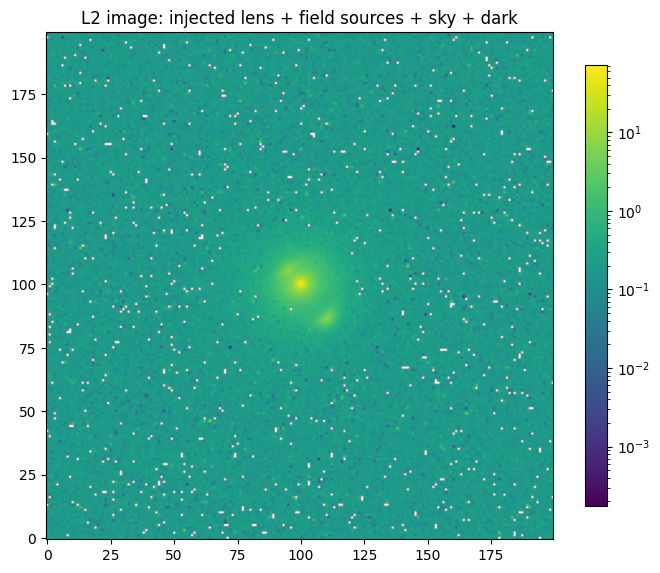

In [16]:
# Example: lens + 200 random field sources on a small detector
roman.n_pix = 200

extra_counts_small = build_extra_counts(
    lens_electrons, 100, 100, npix=200, rng_seed=42)

print("Running simulation with lens + field sources (200×200, no CRDS)...")
im_field, extras_field = simulate_lens_with_field(
    extra_counts_small, band, sca, ma_table_number, coord, date,
    nobj=200, usecrds=False)

roman.n_pix = original_npix

data_f = im_field.data if hasattr(im_field, 'data') else im_field['data']

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im_ax = ax.imshow(data_f, origin="lower", norm=LogNorm())
ax.set_title("L2 image: injected lens + field sources + sky + dark")
plt.colorbar(im_ax, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 8. Multi-band simulation helper

For lens modeling you will want images in multiple filters.  Here is a
convenience function that loops over bands.  You can supply either a
single morphological template (scaled by per-band flux) or
filter-specific PSF-convolved stamps.

In [17]:
def simulate_multiband(lens_stamps, lens_fluxes_maggies, filters,
                       sca, ma_table_number, coord, date,
                       inject_center=(2044, 2044),
                       usecrds=False, rng_seed=42, npix=None,
                       crparam=dict(), **kwargs):
    """Simulate the same lens in multiple Roman bands.

    Parameters
    ----------
    lens_stamps : dict[str, np.ndarray]
        PSF-convolved noiseless stamps keyed by filter name.
        If the morphology is identical across bands, pass the same
        normalized array for each key.
    lens_fluxes_maggies : dict[str, float]
        Total flux in maggies for each filter.
    filters : list[str]
        Filters to simulate (e.g. ['F106', 'F129', 'F158', 'F184']).
    npix : int or None
        Override detector size (None → galsim.roman.n_pix).

    Returns
    -------
    results : dict[str, tuple]
        Keyed by filter name; each value is (image_model, extras).
    """
    results = {}
    cx, cy = inject_center
    eff_npix = npix if npix is not None else roman.n_pix

    for i, filt in enumerate(filters):
        print(f"  Simulating {filt}...")
        stamp = lens_stamps[filt]
        flux = lens_fluxes_maggies[filt]

        abf = romanisim.bandpass.get_abflux(filt, sca)
        rp = rsim_params.read_pattern[ma_table_number]
        etime = rsim_params.read_time * rp[-1][-1]
        expected_electrons = (stamp / np.sum(stamp)) * flux * abf * etime

        # Use a different seed per filter for independent Poisson draws
        ec = build_extra_counts(expected_electrons, cx, cy,
                                npix=eff_npix, rng_seed=rng_seed + i)

        sim_func = (simulate_lens_with_crds if usecrds
                    else simulate_lens_no_crds)
        im, extras = sim_func(
            ec, filt, sca, ma_table_number, coord, date,
            rng_seed=rng_seed, crparam=crparam, **kwargs)
        results[filt] = (im, extras)

    return results

In [18]:
# # Example: 4-band simulation on a small detector
# roman.n_pix = 200

# # TODO this needs to be updated to use the actual PSF-convolved stamps and fluxes for each band
# filters = ['F106', 'F129', 'F158', 'F184']
# # Same AB mag 22 in all bands (replace with your actual SED-derived fluxes)
# fluxes = {f: 10**(-22.0 / 2.5) for f in filters}
# # Same morphology in all bands (replace with per-band PSF-convolved stamps)
# stamps = {f: lens_stamp for f in filters}

# print("Running multi-band simulation...")
# results = simulate_multiband(
#     stamps, fluxes, filters, sca, ma_table_number, coord, date,
#     inject_center=(100, 100), npix=200, crparam=None)

# roman.n_pix = original_npix

# fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
# for ax, filt in zip(axes, filters):
#     im_node = results[filt][0]
#     d = im_node.data if hasattr(im_node, 'data') else im_node['data']
#     sl = (slice(100 - 55, 100 + 55), slice(100 - 55, 100 + 55))
#     cutout = d[sl]
#     bg = np.nanmedian(d)
#     vmax = np.nanpercentile(cutout - bg, 99.5)
#     ax.imshow(cutout - bg, origin="lower", cmap="inferno",
#               vmin=-0.05 * vmax, vmax=vmax)
#     ax.set_title(filt)
#     ax.set_xlabel("x [pix]")
# axes[0].set_ylabel("y [pix]")
# plt.suptitle("Background-subtracted cutouts – multi-band lens simulation",
#              fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

## 9. Full-frame simulation (4088×4088)

Uncomment and run the cell below when you are ready for a production-quality
simulation.  Expect ∼5–15 minutes per filter depending on your machine and
whether cosmic rays are enabled.

In [19]:
# ── Full-frame, single band, no CRDS ───────────────────────────────────
# extra_counts_full = build_extra_counts(lens_electrons, 2044, 2044,
#                                        rng_seed=42)
#
# im_full, extras_full = simulate_lens_no_crds(
#     extra_counts_full, "F158", sca=7, ma_table_number=4,
#     coord=coord, date=date, rng_seed=42, crparam=dict())

# ── Full-frame, single band, WITH CRDS ─────────────────────────────────
# im_crds, extras_crds = simulate_lens_with_crds(
#     extra_counts_full, "F158", sca=7, ma_table_number=4,
#     coord=coord, date=date, rng_seed=42, crparam=dict())

## 10. Data flow summary

```
Your noiseless PSF-convolved stamp (91×91, normalized)
  × (flux_maggies × get_abflux(filter, sca) × exptime)  →  expected electrons (float)
  → Poisson sample to get realized counts (int)          →  extra_counts
  → image.simulate(extra_counts=extra_counts)
      ├─ simulate_counts(): sky + dark + catalog sources (Poisson noise)
      ├─ counts += extra_counts   (integer addition)
      ├─ make_l1():
      │     binomial apportioning to reads  →  distributes photons across time
      │     + read noise + IPC + cosmic rays + nonlinearity + persistence
      └─ make_l2():
            Casertano ramp fitting  →  slopes (DN/s) + variance images
  → L2 image with realistic noise, WCS, and metadata
```

### Key points

| Topic | Detail |
|-------|--------|
| **Input format** | PSF-convolved, noiseless, at 0.11″/pix native scale |
| **Flux conversion** | `expected_electrons = maggies × get_abflux(filter, sca) × exptime` |
| **Poisson noise** | Applied via `np.random.poisson()` on the expected electron stamp *before* injection. This produces integer counts as required by `apportion_counts_to_resultants`, and is the physically correct noise model: the stamp gives the expected photon rate, the Poisson draw gives what actually arrived. |
| **Binomial apportioning** | Distributes the realized integer photons across reads — determines *when* each photon arrived, not *how many* arrived |
| **Instrumental effects** | Read noise, IPC, CRs, nonlinearity, persistence — all applied in L1 |
| **WCS** | Attached to output; world coordinates recoverable |
| **Cosmic rays** | `crparam=dict()` for defaults, `crparam=None` to skip |
| **QE / flat caveat** | `extra_counts` is added *after* `simulate_counts`, so QE/flat modulation is not applied to it. Multiply your stamp by the flat if this matters for your science case. |
